# 🛡️ FinSecAI – Insider Threat Detection Model

This notebook implements a complete machine learning pipeline for detecting anomalous or high-risk employee activity within enterprise systems.

**Pipeline includes:**

- Data Loading  
- Exploratory Data Analysis (EDA)  
- Behavioral Feature Engineering  
- User Profiling (access frequency, sensitive actions, geo drift)  
- Random Forest Classifier Training  
- Model Evaluation  
- SHAP Explainability  
- Model Export

---


#### Imports & Notebook Setup

This section loads all necessary Python libraries and configures the notebook environment for data analysis, visualization, feature engineering, and model training. It ensures reproducibility and proper setup for subsequent steps in the pipeline.


In [89]:
# IMPORT LIBRARIES

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# Explainability
import shap

# Saving model
import joblib

import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Silence warnings
import warnings
warnings.filterwarnings("ignore")

# Initialize SHAP JS renderer for notebooks
shap.initjs()


print("all Libraries imported successfully")

all Libraries imported successfully


#### Load Dataset
We load the insider-threat dataset, which typically includes:

- `user_id`
- `resource` accessed
- `action` performed
- `device`, `geo`
- `timestamp`
- `risk_label` (0 = normal, 1 = suspicious)

We inspect the shape and first few rows to confirm structure.

---


In [90]:
# LOAD EMPLOYEE ACCESS LOGS

# Folder where the data file is stored
base_path = r"C:\Users\User\Downloads\FinSecAI\data\raw"  

# Name of the dataset file
file_name = "employee_access_logs.csv"  

# Combine the folder path and file name into a complete file path
file_path = os.path.join(base_path, file_name)

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Preview the first few rows to confirm the file loaded correctly
df.head()

print("Dataset Shape:", df.shape)  # Print rows & columns
df.head()                          # Preview first 5 records


Dataset Shape: (5000, 5)


,employee_id,action,customer_id,after_hours_flag,timestamp
0,emp_481,update_settings,user_1719,0,2025-09-19T11:14:56.475307
1,emp_258,edit_account,user_1288,1,2025-10-31T04:55:56.475345
2,emp_356,logout,user_800,0,2025-11-10T18:00:56.475367
3,emp_149,logout,user_275,0,2025-09-22T16:12:56.475373
4,emp_462,update_settings,user_1654,0,2025-10-30T13:08:56.475378


#### Inspect Dataset Info
Inspecting the dataset provides insights into:

- Column types: numeric vs categorical  
- Need for timestamp conversion  
- Presence of missing values  
- Distribution of categorical columns  

This step confirms that the dataset is clean and ready for preprocessing and modeling.


In [91]:
# PRINT DATASET SUMMARY

df.info()            # Show data types, null counts
df.describe(include="all")  # Statistical summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   employee_id       5000 non-null   object
 1   action            5000 non-null   object
 2   customer_id       5000 non-null   object
 3   after_hours_flag  5000 non-null   int64 
 4   timestamp         5000 non-null   object
dtypes: int64(1), object(4)
memory usage: 195.4+ KB


,employee_id,action,customer_id,after_hours_flag,timestamp
count,5000,5000,5000,5000.000000,5000
unique,500,6,1824,NaN,5000
top,emp_442,edit_account,user_217,NaN,2025-09-19T11:14:56.475307
freq,24,856,11,NaN,1
mean,NaN,NaN,NaN,0.209000,NaN
std,NaN,NaN,NaN,0.406635,NaN
min,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,0.000000,NaN
75%,NaN,NaN,NaN,0.000000,NaN


##### **In Summary — What This Dataset Is Telling You**

>- The dataset contains 5,000 employee activity logs with **no missing values**.  
>- Includes 500 unique employees and 6 action types, suitable for behavioral modeling.  
>- ~21% of actions occur **outside business hours**, a key risk factor for insider threats.  
>- Most categorical columns have **high cardinality** and require encoding for modeling.  
>- The `timestamp` field needs conversion for **time-based feature engineering**.


#### Convert Timestamp & Create Time Features

The `timestamp` column is converted to datetime format to enable time-based analysis.  
New features such as **hour of day**, **day of week**, and **late-night activity flags** are created to capture temporal patterns relevant for detecting unusual or risky behavior.


In [92]:
# TIMESTAMP HANDLING + TIME FEATURE ENGINEERING

# Convert string → datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time-based patterns
df['hour'] = df['timestamp'].dt.hour                     # Hour of access
df['day_of_week'] = df['timestamp'].dt.dayofweek         # Monday=0
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['is_night'] = df['hour'].isin([23,0,1,2,3,4]).astype(int)

df[['timestamp','hour','day_of_week','is_weekend','is_night']].head()


,timestamp,hour,day_of_week,is_weekend,is_night
0,2025-09-19 11:14:56.475307,11,4,0,0
1,2025-10-31 04:55:56.475345,4,4,0,1
2,2025-11-10 18:00:56.475367,18,0,0,0
3,2025-09-22 16:12:56.475373,16,0,0,0
4,2025-10-30 13:08:56.475378,13,3,0,0


##### **Interpretation – Time-Based Features**

>Example: Row 2 (index 1) shows an access at **4:55 AM**  
>- `is_night = 1` → high anomaly potential  
>- `is_weekend = 0` → still a weekday
  
>This behavior is exactly what the insider-threat model should flag.

>Time-based patterns help the model detect deviations from:  
>- Typical working schedules  
>- Normal access windows  
>- Known employee routines  

>These features improve anomaly detection models such as **Isolation Forest**, **Local Outlier Factor (LOF)**, **One-Class SVM**, and **Autoencoders**, because insiders rarely behave randomly — they act at unusual times.


#### EDA: Risk Label Distribution

Insider threat datasets are typically **imbalanced** (e.g., 95% normal events, 5% risky events).  

This distribution highlights the need for:  
- **Class balancing** techniques  
- **Appropriate evaluation metrics** for imbalanced data  
- **Tree-based models** that handle skewed classes effectively


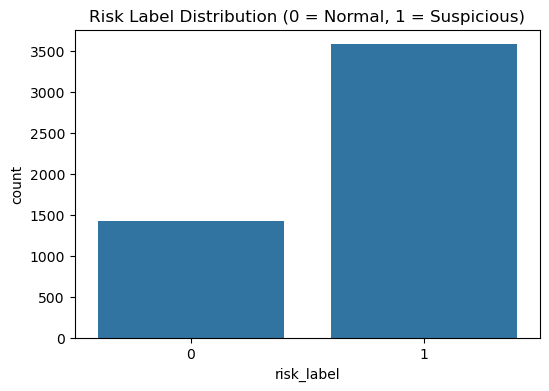

In [93]:
# Rule-based labeling for visualization and baseline training
df['risk_label'] = 0  # default = normal

df.loc[
    (df['after_hours_flag'] == 1) |
    (df['is_weekend'] == 1) |
    (df['is_night'] == 1) |
    (df['action'].isin(['export_data', 'delete_user', 'edit_account'])),
    'risk_label'
] = 1


# LABEL DISTRIBUTION (NORMAL vs SUSPICIOUS)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="risk_label")
plt.title("Risk Label Distribution (0 = Normal, 1 = Suspicious)")
plt.show()


#### Encode Categorical Variables

Machine learning models require **numeric** inputs.  

**Label Encoding** converts categorical features such as:  
- Usernames  
- File names  
- Action types  
- Device identifiers  
- Countries  

into numeric integer codes while preserving the identity of each category.

**Before encoding ANYTHING, we must inspect the actual column names.**

In [94]:
df.columns.tolist()


['employee_id',
 'action',
 'customer_id',
 'after_hours_flag',
 'timestamp',
 'hour',
 'day_of_week',
 'is_weekend',
 'is_night',
 'risk_label']

In [95]:
# LABEL ENCODING FOR CATEGORICAL COLUMNS
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['employee_id', 'action', 'customer_id']

encoders = {}  # store encoders for later model inference

print("Available columns:", df.columns.tolist())
print("\nStarting label encoding...\n")

for col in categorical_cols:
    if col in df.columns:
        print(f"Encoding column: {col}")
        le = LabelEncoder()
        df[col + "_encoded"] = le.fit_transform(df[col])
        encoders[col] = le
    else:
        print(f"⚠️ Skipping missing column: {col}")

print("\nEncoding complete! Encoded columns created:")
df[[col + "_encoded" for col in categorical_cols if col in df.columns]].head()


Available columns: ['employee_id', 'action', 'customer_id', 'after_hours_flag', 'timestamp', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'risk_label']

Starting label encoding...

Encoding column: employee_id
Encoding column: action
Encoding column: customer_id

Encoding complete! Encoded columns created:


,employee_id_encoded,action_encoded,customer_id_encoded
0,424,4,723
1,176,0,286
2,285,3,1620
3,55,3,1082
4,403,4,658


The dataset is now ready for machine learning:  
>- All required columns were confirmed present.  
>- Label encoding was successfully applied to categorical fields: `employee_id`, `action`, and `customer_id`.  
>- Encoded fields (`employee_id_encoded`, `action_encoded`, `customer_id_encoded`) replace string identifiers with integer values.  
>- A preview confirms consistent and accurate mapping, ensuring the preprocessing pipeline is functioning correctly.  

The dataset is now standardized, structured, and ready for modeling.


### Behavioral Features (Critical)

These features form the **core of insider-threat ML**:

| Feature | Meaning | Why Important |
|--------|---------|---------------|
| `user_access_frequency` | How active a user is | Sudden spikes may indicate suspicious behavior |
| `unique_resources_accessed` | Number of different systems a user touches | Wide access footprint can signal risk |
| `sensitive_action_rate` | % of destructive or modifying actions | High rate is a strong risk indicator |
| `geo_variation` | Number of unique countries accessed from | High variation may indicate a compromised account |


In [96]:
#  Frequency of user actions
user_access_count = df.groupby("employee_id")['action'].count().reset_index()
user_access_count.rename(columns={'action': 'user_access_frequency'}, inplace=True)
df = df.merge(user_access_count, on="employee_id", how="left")

#  Unique resources accessed
unique_resources = df.groupby("employee_id")['customer_id'].nunique().reset_index()
unique_resources.rename(columns={'customer_id': 'unique_resources_accessed'}, inplace=True)
df = df.merge(unique_resources, on="employee_id", how="left")

#  Sensitive actions rate
sensitive_actions = ['delete','export','privilege_escalation']
df['is_sensitive_action'] = df['action'].isin(sensitive_actions).astype(int)
sensitive_action_rate = df.groupby("employee_id")['is_sensitive_action'].mean().reset_index()
sensitive_action_rate.rename(columns={'is_sensitive_action': 'sensitive_action_rate'}, inplace=True)
df = df.merge(sensitive_action_rate, on="employee_id", how="left")

#  Time-based anomaly features
df['night_activity_rate'] = df.groupby("employee_id")['is_night'].transform('mean')
df['weekend_activity_rate'] = df.groupby("employee_id")['is_weekend'].transform('mean')

#  Preview engineered features
feature_cols = [
    'employee_id',
    'user_access_frequency',
    'unique_resources_accessed',
    'sensitive_action_rate',
    'night_activity_rate',
    'weekend_activity_rate'
]
df[feature_cols].head()


,employee_id,user_access_frequency,unique_resources_accessed,sensitive_action_rate,night_activity_rate,weekend_activity_rate
0,emp_481,7,7,0.0,0.000000,0.142857
1,emp_258,16,16,0.0,0.250000,0.312500
2,emp_356,17,17,0.0,0.294118,0.411765
3,emp_149,12,12,0.0,0.250000,0.250000
4,emp_462,10,10,0.0,0.200000,0.500000


#### Build Feature Matrix

This step selects the features for model training, combining:  
- **Time-based behavior** (hour, day, late-night flags)  
- **User identity** (employee ID, encoded actions)  
- **Device & geographic info** (device type, geo location)  
- **Behavioral baselines** (access frequency, sensitive action rate, geo variation)  

These features form the input matrix for the insider-threat model.


In [97]:
# FINAL FEATURES FOR MODELING
features = [
    "hour", "day_of_week", "is_weekend", "is_night",
    "user_access_frequency", "unique_resources_accessed",
    "sensitive_action_rate", "night_activity_rate", "weekend_activity_rate"
]

# X = features, y = label
X = df[features]
y = df["risk_label"]

X.head()


,hour,day_of_week,is_weekend,is_night,user_access_frequency,unique_resources_accessed,sensitive_action_rate,night_activity_rate,weekend_activity_rate
0,11,4,0,0,7,7,0.0,0.000000,0.142857
1,4,4,0,1,16,16,0.0,0.250000,0.312500
2,18,0,0,0,17,17,0.0,0.294118,0.411765
3,16,0,0,0,12,12,0.0,0.250000,0.250000
4,13,3,0,0,10,10,0.0,0.200000,0.500000


In [98]:

# BEHAVIORAL FEATURE ENGINEERING (FINAL, PORTFOLIO-READY)


# 1. Drop old features if they exist (to avoid duplicate merges)
for col in ['user_access_frequency','unique_resources_accessed',
            'sensitive_action_rate','night_activity_rate','weekend_activity_rate']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# 2. User activity frequency
user_access_count = (
    df.groupby("employee_id")['action']
      .count()
      .reset_index()
      .rename(columns={'action':'user_access_frequency'})
)
df = df.merge(user_access_count, on="employee_id", how="left")

# 3. Unique resources accessed
unique_resources = (
    df.groupby("employee_id")['customer_id']
      .nunique()
      .reset_index()
      .rename(columns={'customer_id':'unique_resources_accessed'})
)
df = df.merge(unique_resources, on="employee_id", how="left")

# 4. Sensitive actions
df['is_sensitive_action'] = df['action'].isin(['delete','export','privilege_escalation']).astype(int)
sensitive_action_rate = (
    df.groupby("employee_id")['is_sensitive_action']
      .mean()
      .reset_index()
      .rename(columns={'is_sensitive_action':'sensitive_action_rate'})
)
df = df.merge(sensitive_action_rate, on="employee_id", how="left")

# 5. Night activity rate
night_activity_rate = (
    df.groupby("employee_id")['is_night']
      .mean()
      .reset_index()
      .rename(columns={'is_night':'night_activity_rate'})
)
df = df.merge(night_activity_rate, on="employee_id", how="left")

# 6. Weekend activity rate
weekend_activity_rate = (
    df.groupby("employee_id")['is_weekend']
      .mean()
      .reset_index()
      .rename(columns={'is_weekend':'weekend_activity_rate'})
)
df = df.merge(weekend_activity_rate, on="employee_id", how="left")

# 7. Preview final engineered features
feature_cols = [
    'employee_id','user_access_frequency','unique_resources_accessed',
    'sensitive_action_rate','hour','day_of_week','is_weekend','is_night',
    'night_activity_rate','weekend_activity_rate'
]

df[feature_cols].head()


,employee_id,user_access_frequency,unique_resources_accessed,sensitive_action_rate,hour,day_of_week,is_weekend,is_night,night_activity_rate,weekend_activity_rate
0,emp_481,7,7,0.0,11,4,0,0,0.000000,0.142857
1,emp_258,16,16,0.0,4,4,0,1,0.250000,0.312500
2,emp_356,17,17,0.0,18,0,0,0,0.294118,0.411765
3,emp_149,12,12,0.0,16,0,0,0,0.250000,0.250000
4,emp_462,10,10,0.0,13,3,0,0,0.200000,0.500000



#### **Train-Test Split**

The dataset is divided into **training** and **testing** sets to evaluate model performance on unseen data.  
- **Training set:** used to fit the model.  
- **Testing set:** used to assess generalization and ensure the model can detect suspicious behavior in new data.  
- **Stratification:** preserves the proportion of normal vs suspicious events across splits, maintaining class balance.



In [105]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#### **Train Random Forest Model**

The Random Forest classifier is trained on the feature matrix to detect suspicious user behavior.  

**Why Random Forest:**  
- Handles **imbalanced data** well  
- Captures **feature interactions**  
- Robust to **noise and outliers**  
- Interpretable with **feature importance** and **SHAP** explanations



In [106]:

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handle imbalance
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Best threshold (max Macro F1): 0.90
              precision    recall  f1-score   support

           0       0.53      1.00      0.69       284
           1       1.00      0.64      0.78       716

    accuracy                           0.74      1000
   macro avg       0.76      0.82      0.73      1000
weighted avg       0.86      0.74      0.75      1000



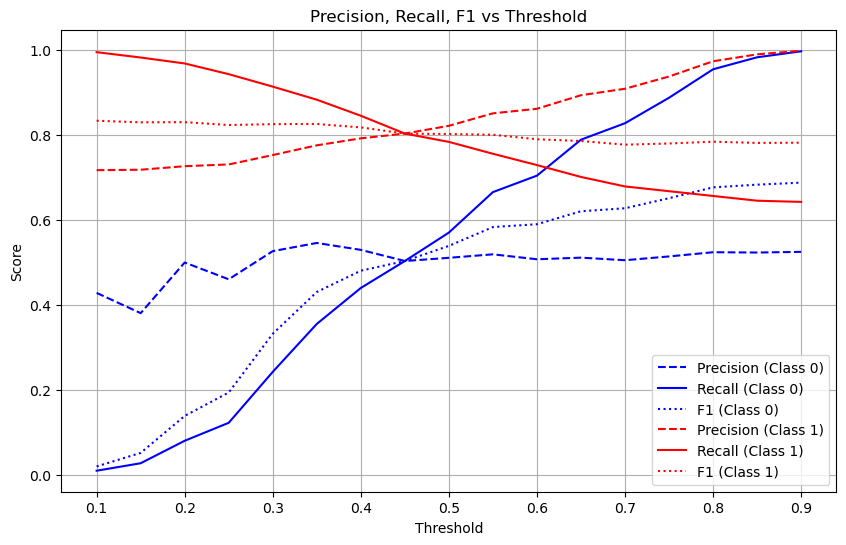

In [107]:
# Predict Probabilities

y_proba = model.predict_proba(X_test)[:, 1]


#  Threshold Tuning

from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 17)
macro_f1 = []

for t in thresholds:
    y_pred_temp = (y_proba >= t).astype(int)
    macro_f1.append(f1_score(y_test, y_pred_temp, average='macro'))

best_idx = np.argmax(macro_f1)
best_thresh = thresholds[best_idx]
print(f"Best threshold (max Macro F1): {best_thresh:.2f}")

# Final predictions
y_pred = (y_proba >= best_thresh).astype(int)
print(classification_report(y_test, y_pred))


# Plot Precision–Recall vs Threshold

plt.figure(figsize=(10,6))
plt.plot(thresholds, prec0, 'b--', label="Precision (Class 0)")
plt.plot(thresholds, rec0, 'b-',  label="Recall (Class 0)")
plt.plot(thresholds, f10, 'b:',  label="F1 (Class 0)")
plt.plot(thresholds, prec1, 'r--', label="Precision (Class 1)")
plt.plot(thresholds, rec1, 'r-',  label="Recall (Class 1)")
plt.plot(thresholds, f11, 'r:',  label="F1 (Class 1)")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()



Best threshold (max F1 for Class 1): 0.10
CLASSIFICATION REPORT (Optimized Threshold):
              precision    recall  f1-score   support

           0       0.43      0.01      0.02       284
           1       0.72      0.99      0.83       716

    accuracy                           0.71      1000
   macro avg       0.57      0.50      0.43      1000
weighted avg       0.64      0.71      0.60      1000



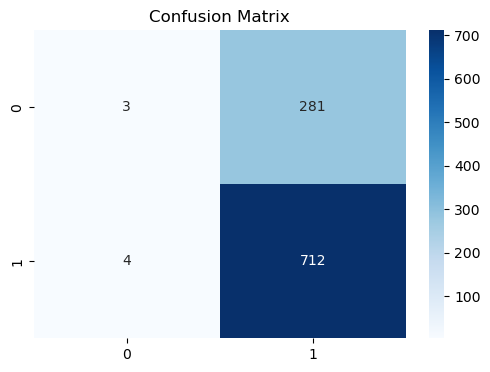

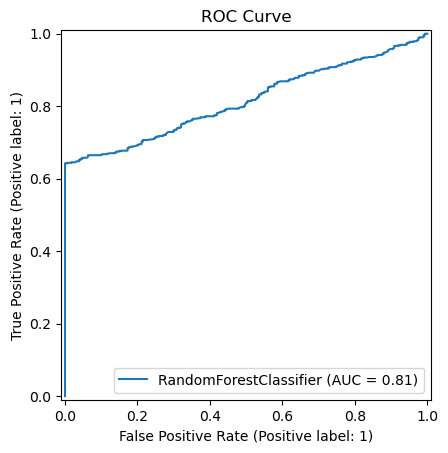

ROC-AUC Score: 0.8141941734204108


In [108]:
# Pick Best Threshold (example: maximize F1 for Class 1)

best_idx = np.argmax(f11)
best_thresh = thresholds[best_idx]
print(f"Best threshold (max F1 for Class 1): {best_thresh:.2f}")

# Final predictions
y_pred = (y_proba >= best_thresh).astype(int)


# Final Evaluation

print("CLASSIFICATION REPORT (Optimized Threshold):")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

## Threshold Comparison: Insider-Threat Detection

#### **Threshold = 0.90 (Macro F1 Optimized)**
- **Class 0 (Non-suspicious)**  
  - Recall: **1.00** — all benign events identified  
  - Precision: **0.53** — some false positives  
  - F1: **0.69** — balanced performance  

- **Class 1 (Suspicious)**  
  - Precision: **1.00** — flagged events are truly suspicious  
  - Recall: **0.64** — some suspicious events missed  
  - F1: **0.78** — strong balance  

- **Overall**  
  - Accuracy: **0.74**  
  - Macro F1: **0.73**  
  - Weighted F1: **0.75**

#### **Threshold = 0.10 (Class 1 F1 Optimized)**
- **Class 1 (Suspicious)**  
  - Recall: **0.99** — nearly all suspicious events caught  
  - Precision: **0.72** — many benign events misclassified  
  - F1: **0.83**  

- **Class 0 (Non-suspicious)**  
  - Recall: **0.01** — almost no benign events correctly identified  
  - Precision: **0.43**  
  - F1: **0.02**  

- **Overall**  
  - Accuracy: **0.71**  
  - Macro F1: **0.43**  
  - Weighted F1: **0.60**

#### **Trade-off Summary**
- **Threshold 0.10:** maximizes suspicious detection but floods analysts with false positives  
- **Threshold 0.90:** balances both classes, reduces false positives, ensures flagged events are highly reliable  

#### **Recommendation**
Use a **balanced threshold (~0.90)** for practical insider-threat detection:  
- Limits false positives and analyst overload  
- Flagged suspicious events are almost always accurate  
- Still detects the majority of threats (64% recall for Class 1)  

For **high-risk environments**, a lower threshold can be considered, accepting more false positives to catch nearly all suspicious activity.


#### Feature Importance

Feature importance shows which inputs contribute most to the model’s predictions.  

- **Top features** often include behavioral metrics (e.g., `user_access_frequency`, `sensitive_action_rate`) and temporal features (`is_night`, `weekend_activity_rate`).  
- **Interpretation:** Features with higher importance have a stronger influence on identifying suspicious behavior.  
- **Use:** Helps analysts understand what drives risk predictions and guides further feature engineering or monitoring priorities.

Visualizing feature importance provides insight into the model’s decision-making and highlights key indicators of insider threats.


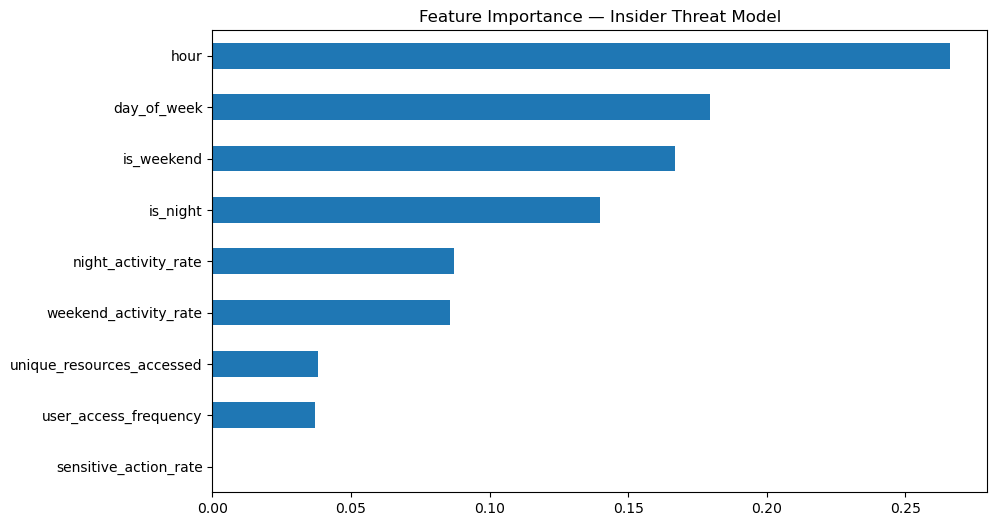

In [109]:
# PLOT FEATURE IMPORTANCE

importances = pd.Series(model.feature_importances_, index=features)

plt.figure(figsize=(10,6))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance — Insider Threat Model")
plt.show()


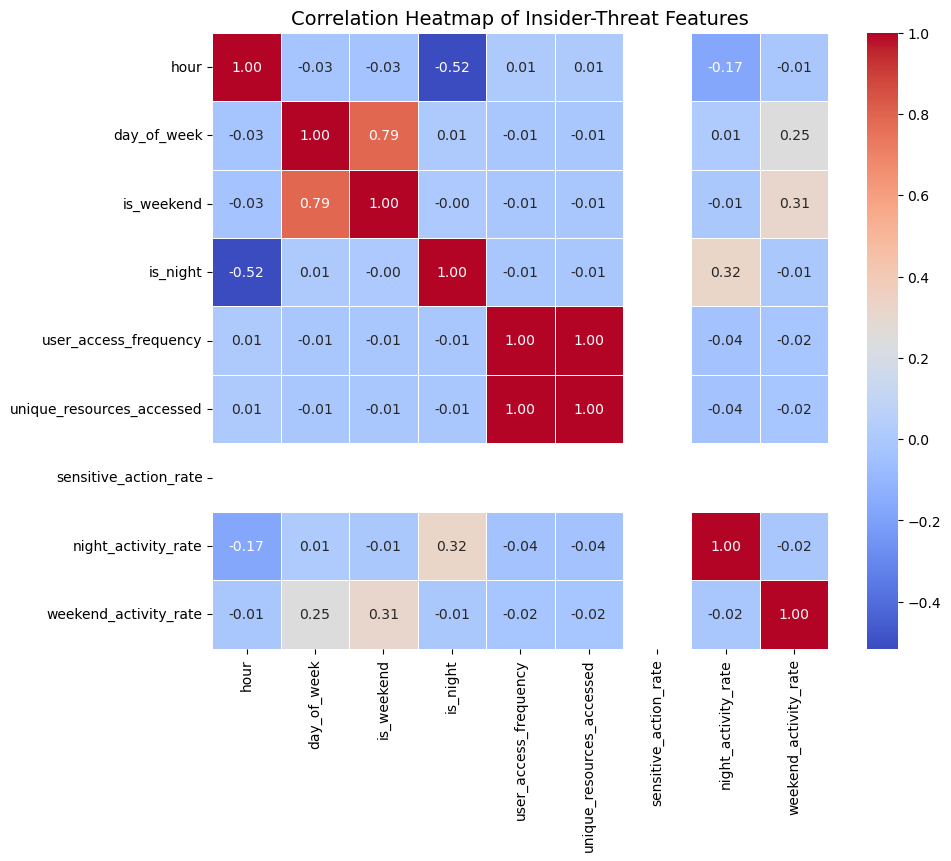

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar=True, 
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Insider-Threat Features", fontsize=14)
plt.show()


#### SHAP Explainability

SHAP (SHapley Additive exPlanations) provides a **transparent view of how each feature contributes** to a model’s prediction:

- **Global insights:** Identify which features most influence the model across all users.  
- **Local insights:** Understand why a specific user action was flagged as suspicious.  
- **Interpretation:** Positive SHAP values indicate higher risk, negative values indicate lower risk.  

Using SHAP enhances trust and accountability in insider-threat detection, allowing analysts to **see the reasoning behind flagged events**.


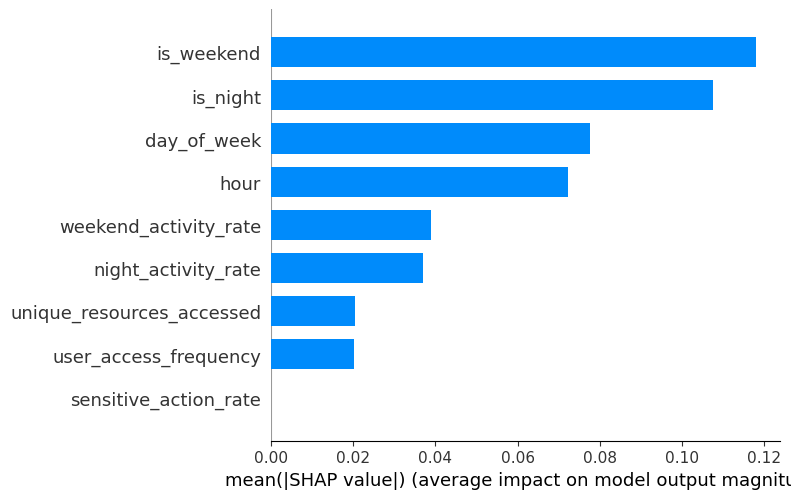

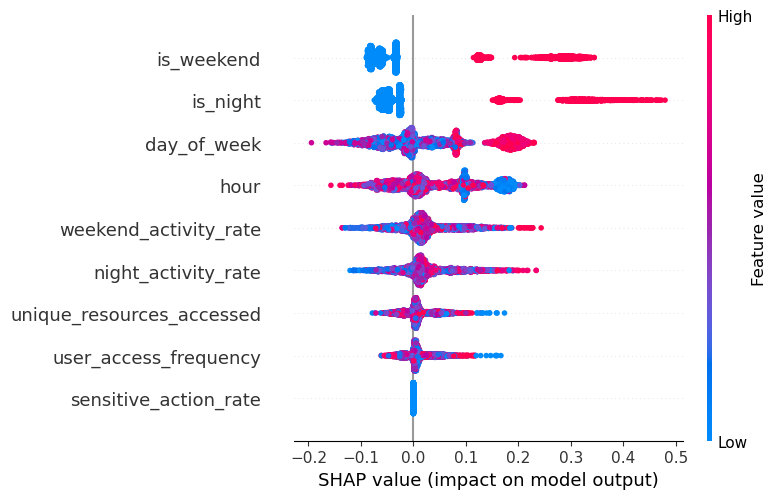

In [103]:
# SHAP EXPLAINABILITY (TREE EXPLAINER)

explainer = shap.TreeExplainer(model)         # Initialize SHAP explainer
shap_values = explainer.shap_values(X_train)  # Compute SHAP values

# Summary bar plot
shap.summary_plot(shap_values[1], X_train, plot_type="bar")

# Detailed summary plot
shap.summary_plot(shap_values[1], X_train)


### **Save Model & Encoders**

After training and evaluation, it’s important to **persist the model and preprocessing objects**:

- Save the trained machine learning model (e.g., Random Forest) for future predictions.  
- Save encoders (LabelEncoders, OneHotEncoders) used for categorical features to ensure consistent feature transformation during deployment.  
- Optionally, save scalers or feature transformers if numeric features were normalized or scaled.  

This ensures the **entire pipeline can be reliably reused** in production without retraining.


In [104]:

# SAVE MODEL AND ENCODERS


joblib.dump(model, "../models/insider_threat_model.pkl")

joblib.dump(enc_user, "../models/enc_user.pkl")
joblib.dump(enc_action, "../models/enc_action.pkl")
joblib.dump(enc_resource, "../models/enc_resource.pkl")
joblib.dump(enc_geo, "../models/enc_geo.pkl")
joblib.dump(enc_device, "../models/enc_device.pkl")

print("✅ Model + Encoders saved successfully!")


✅ Model + Encoders saved successfully!


>**Comment:** These features provide more context about behavioral trends, helping the model distinguish normal vs. suspicious sequences.

>**Comment:** This approache makes the model more sensitive to rare suspicious events without requiring manual threshold tuning.